# Import Libraries

In [ ]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Load Dataset


In [21]:
#read the csv and perform all the numpy and pandas functions
df = pd.read_csv("AI_Impact_on_Jobs_2030.csv", delimiter=',')

print("df: ", df)
print("df.head():  ", df.head())
print("df.info() : ", df.info())
print("df.describe(): ", df.describe())
print("df.shape:  ", df.shape)
print("df.columns: ", df.columns)
print("Null values:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())


df:                  Job_Title  Average_Salary  Years_Experience Education_Level  \
0          Security Guard           45795                28        Master's   
1      Research Scientist          133355                20             PhD   
2     Construction Worker          146216                 2     High School   
3       Software Engineer          136530                13             PhD   
4       Financial Analyst           70397                22     High School   
...                   ...             ...               ...             ...   
2995               Doctor          111319                 6      Bachelor's   
2996        UX Researcher           44363                29             PhD   
2997       Data Scientist           61325                23        Master's   
2998     Graphic Designer          110296                 7             PhD   
2999     Graphic Designer          123909                25             PhD   

      AI_Exposure_Index  Tech_Growth_Factor  A

# Applied Encoding on Categorial Columns

In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Risk_Category_encoded'] = le.fit_transform(df['Risk_Category'])

#drop the original risk category column 
df = df.drop(columns=['Risk_Category']) 

from sklearn.preprocessing import OrdinalEncoder

categories_order = [['High School', "Bachelor's", "Master's", 'PhD']]
oe = OrdinalEncoder(categories=categories_order)

df['Education_Level_ord'] = oe.fit_transform(df[['Education_Level']])

#drop the original education level column
df = df.drop(columns=['Education_Level'])        


#Job title 
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, drop='first')
ohe_array = ohe.fit_transform(df[['Job_Title']])

ohe_df = pd.DataFrame(
    ohe_array, 
    columns=ohe.get_feature_names_out(['Job_Title']))

#drop the original Job Title column
df = df.drop(columns=['Job_Title'])              
df = pd.concat([df.reset_index(drop=True), ohe_df.reset_index(drop=True)], axis=1)

# Seaborn Graphs (Visualization)

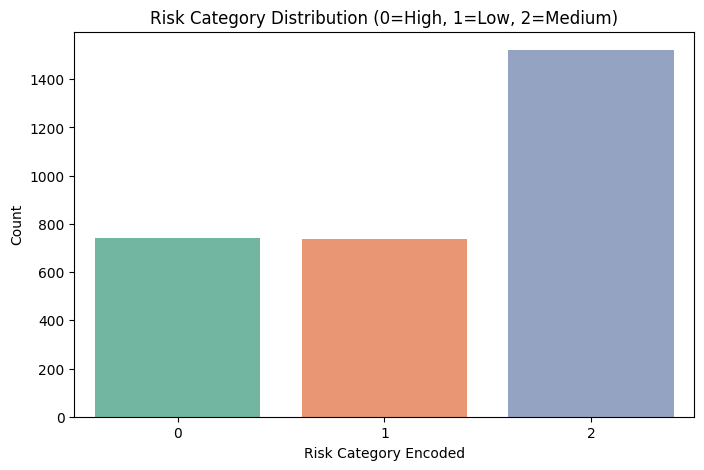

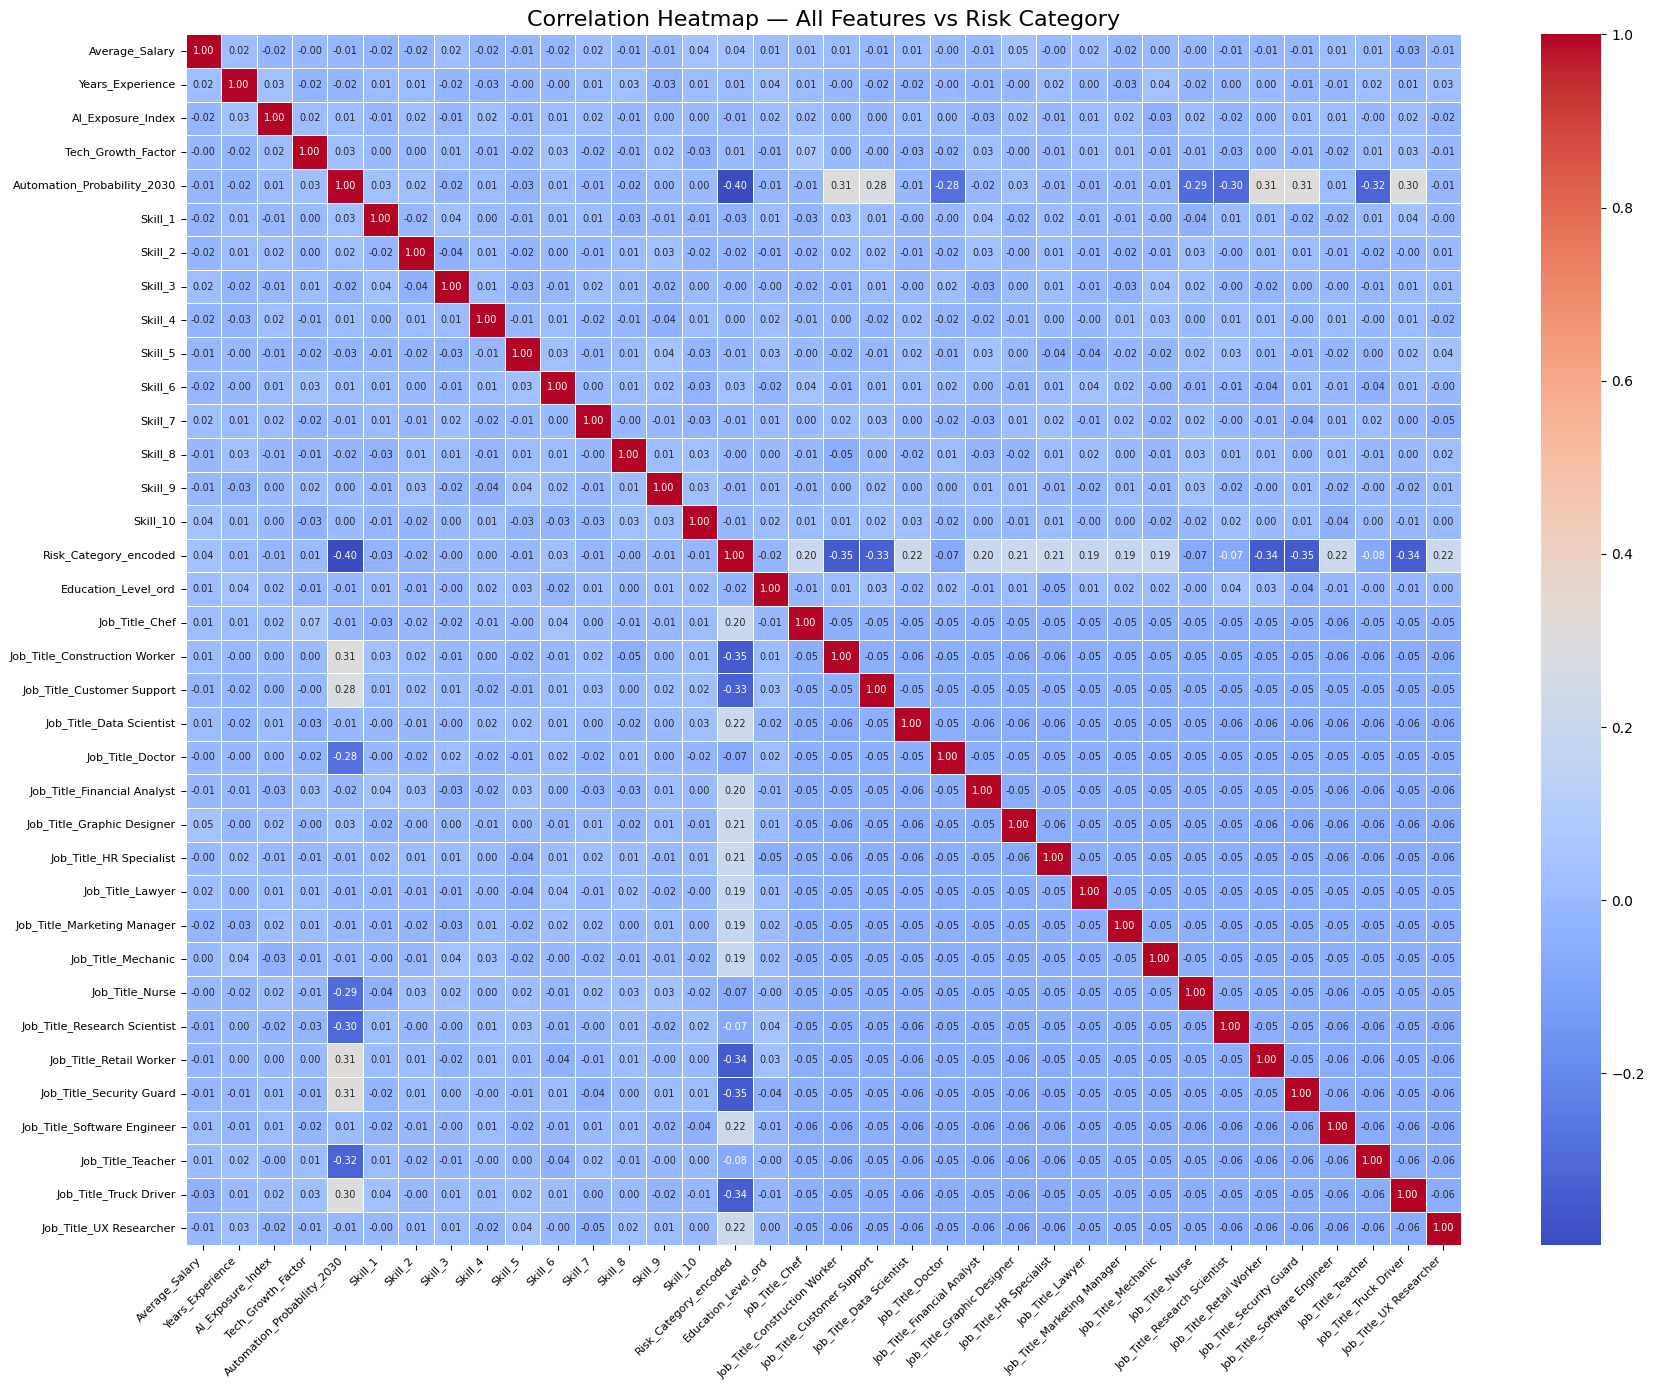

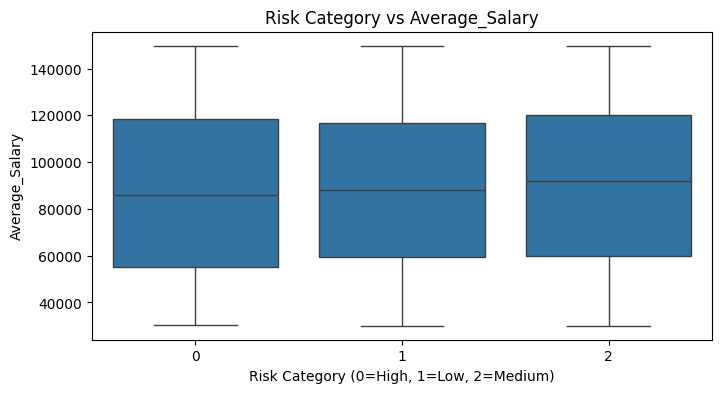

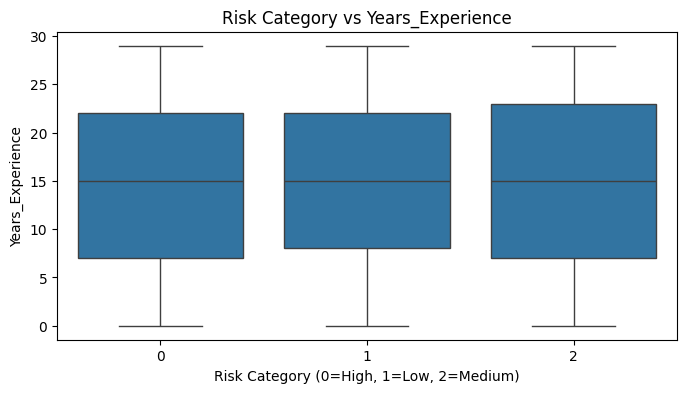

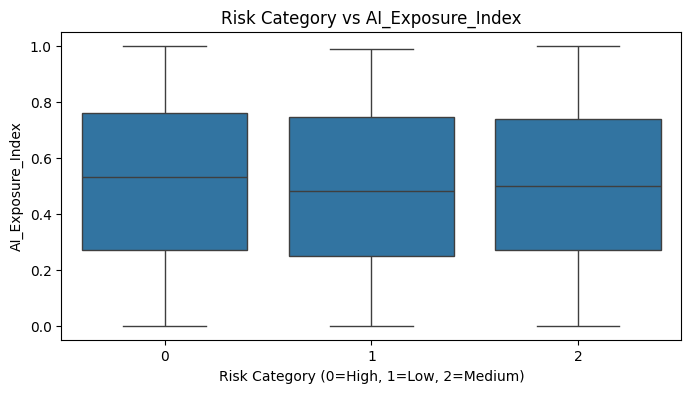

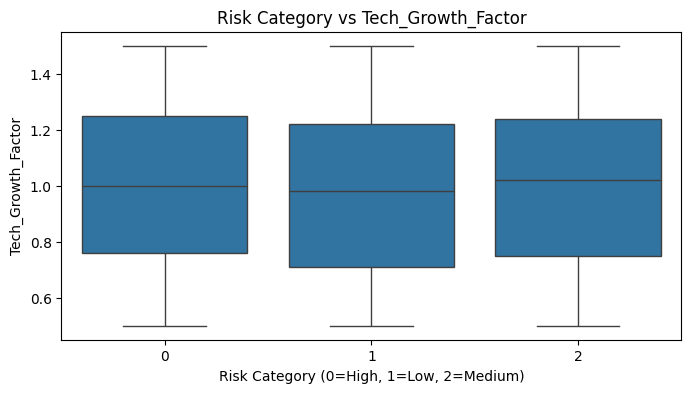

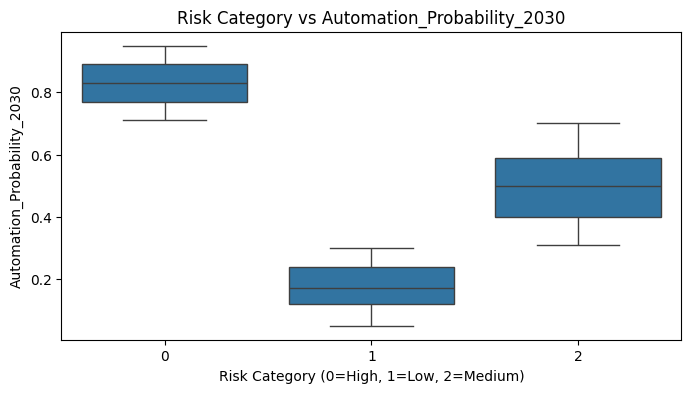

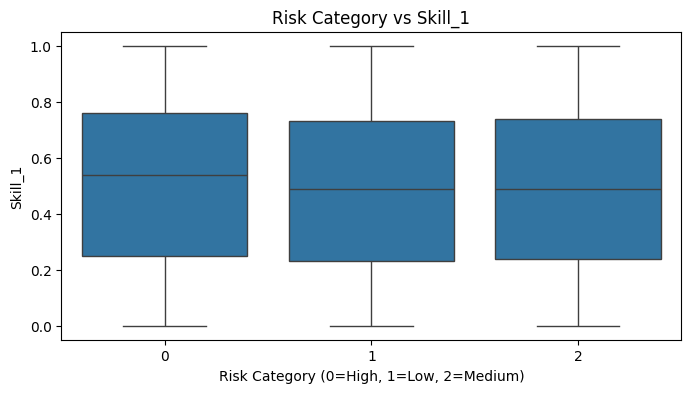

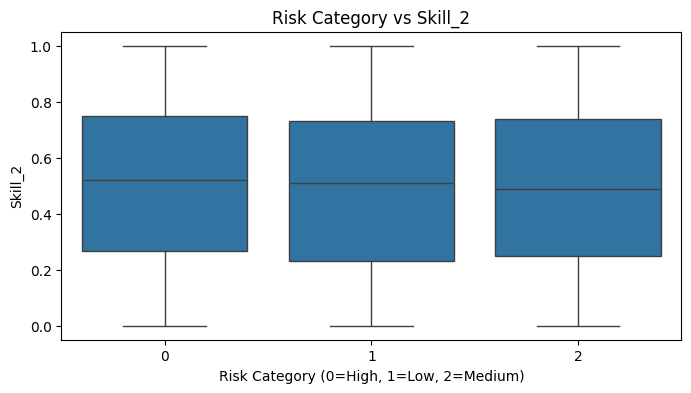

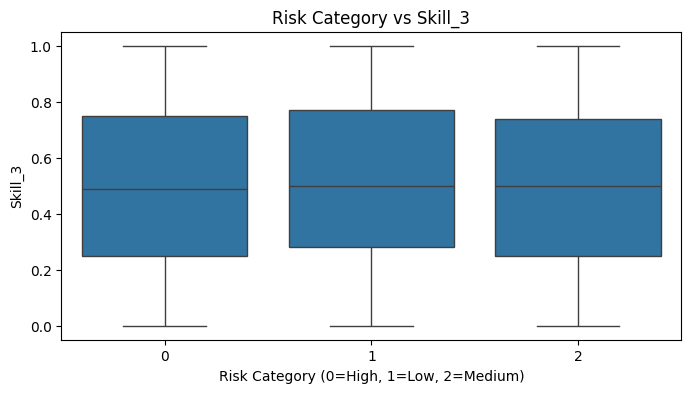

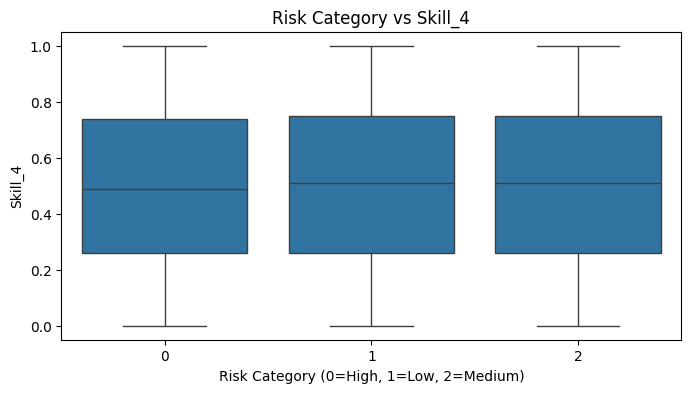

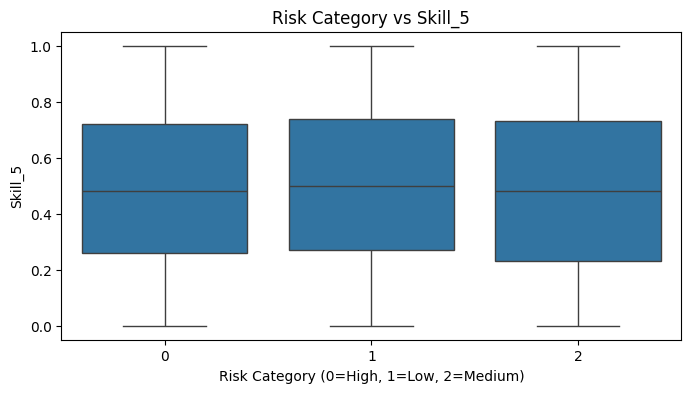

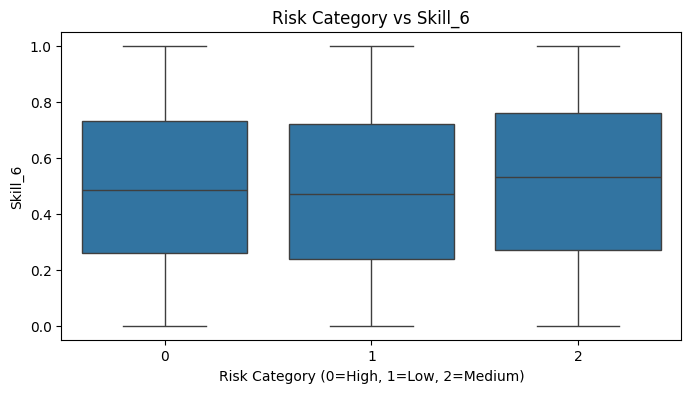

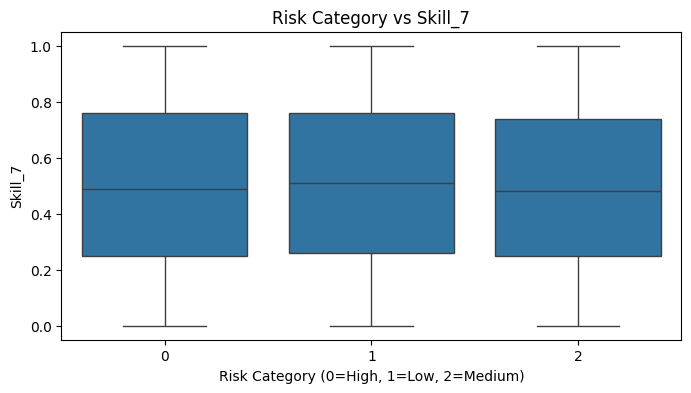

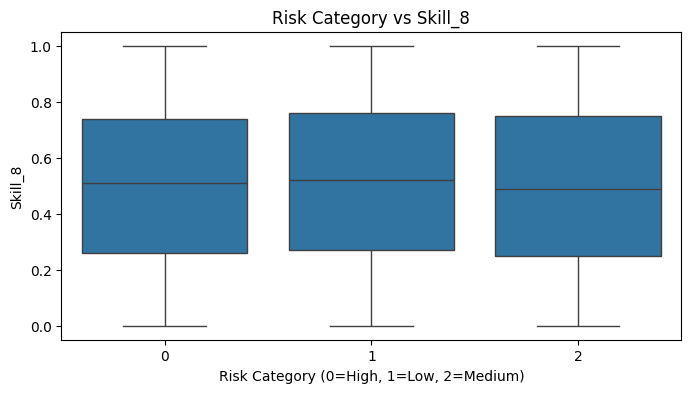

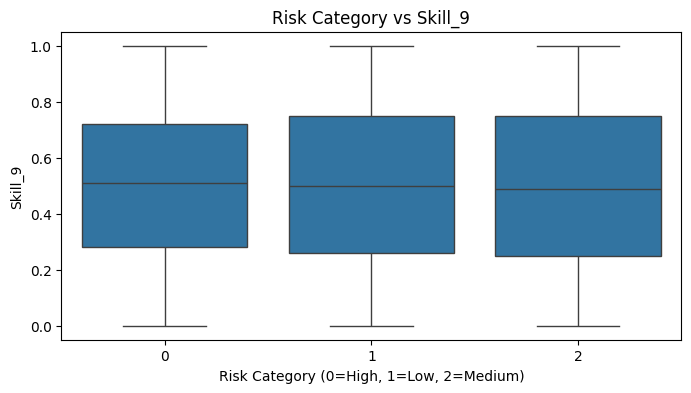

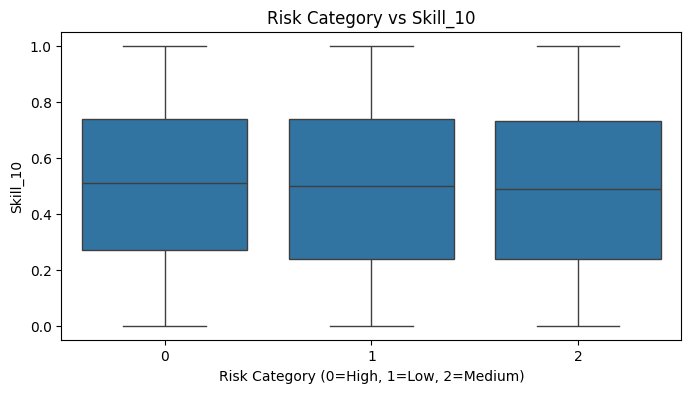

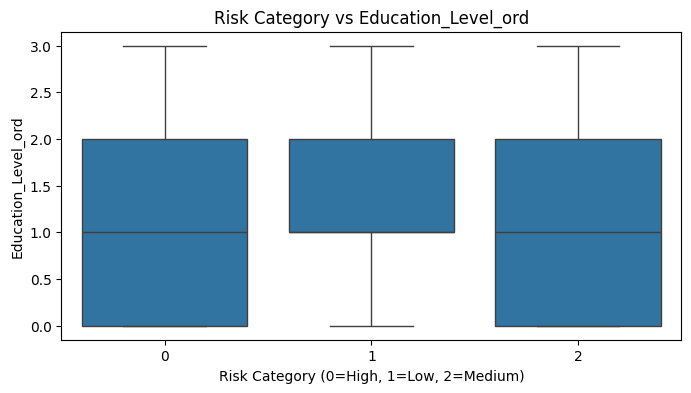

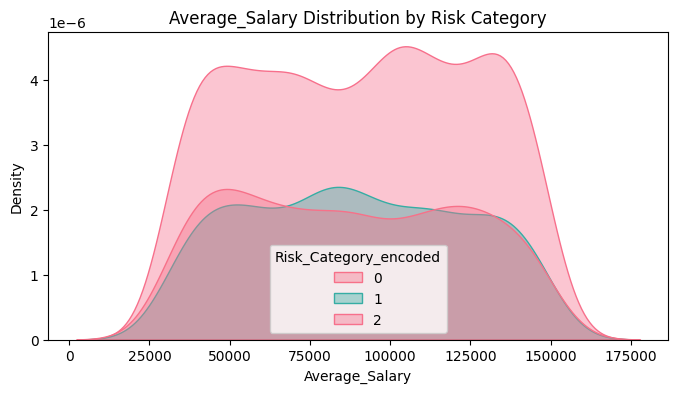

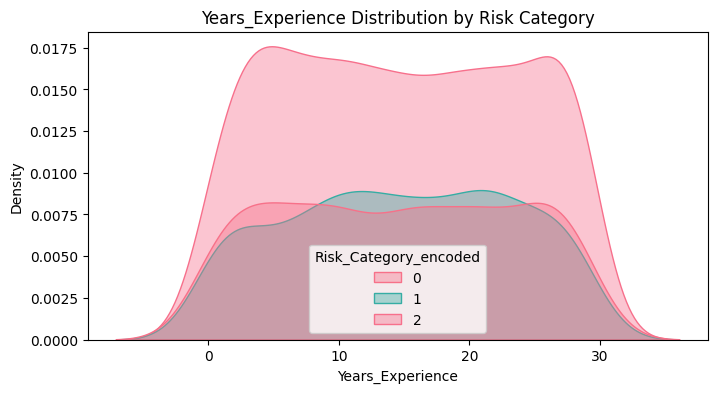

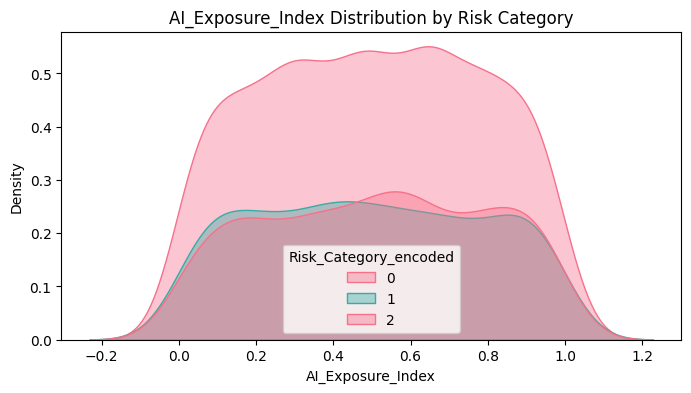

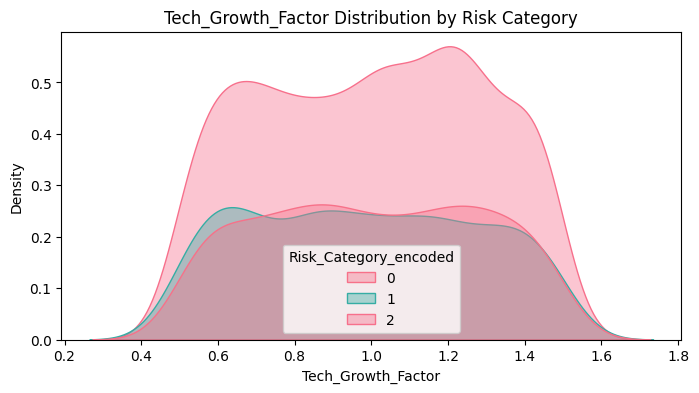

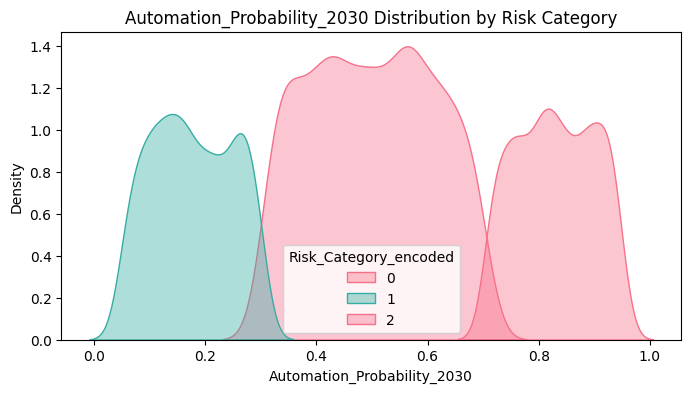

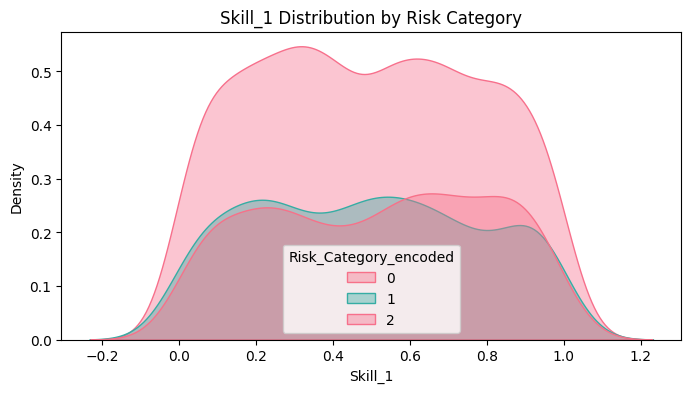

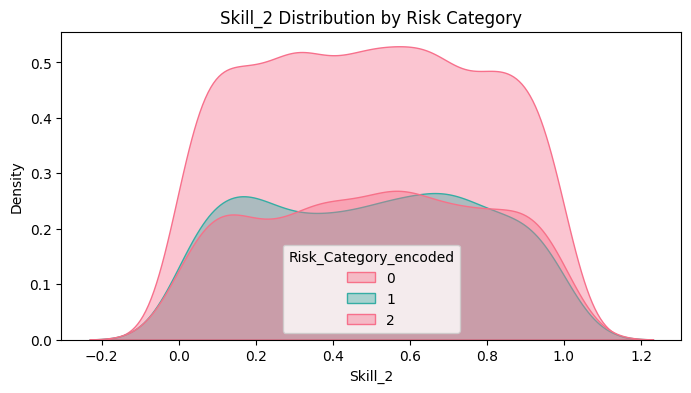

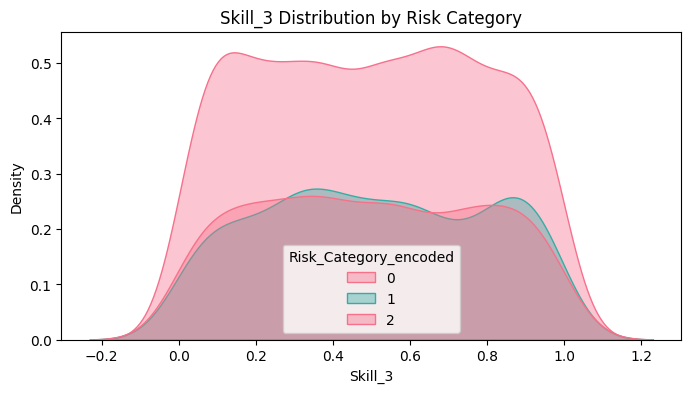

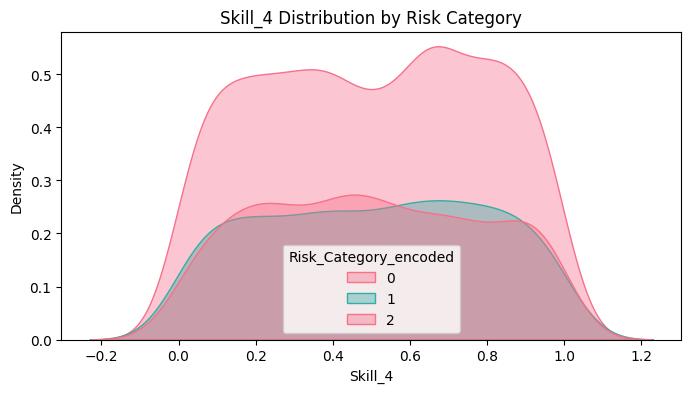

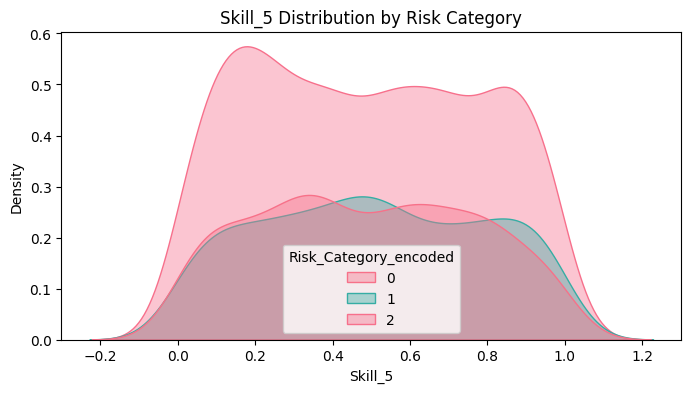

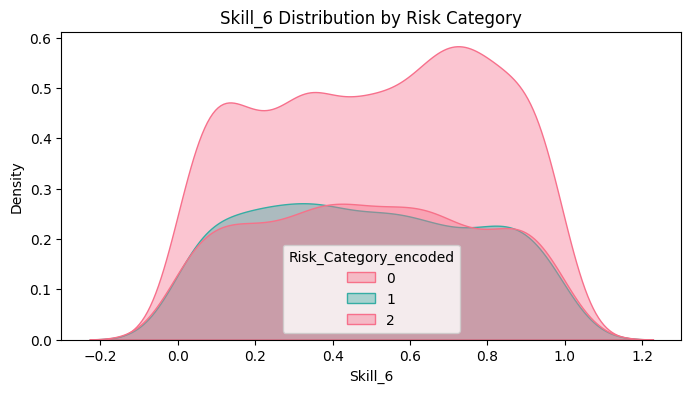

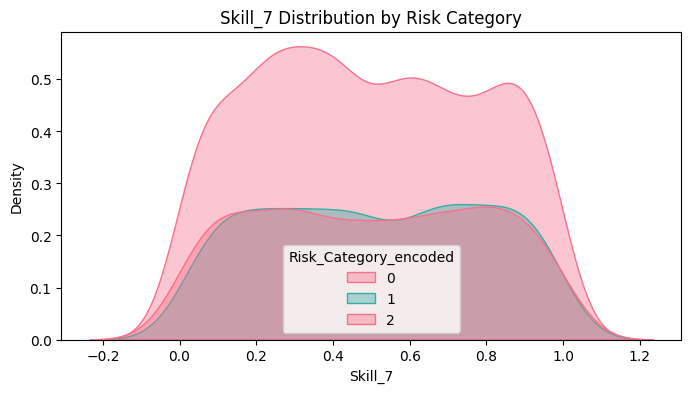

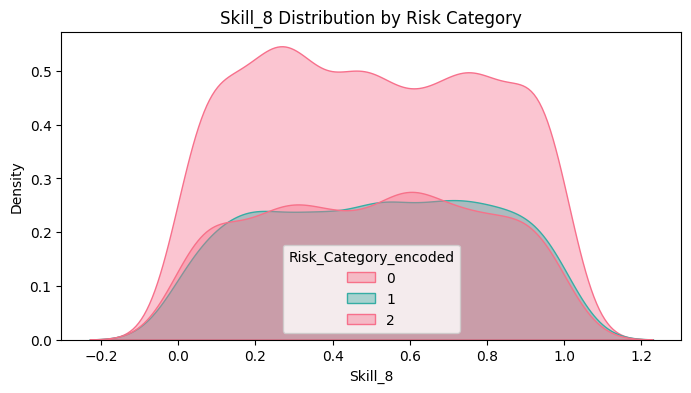

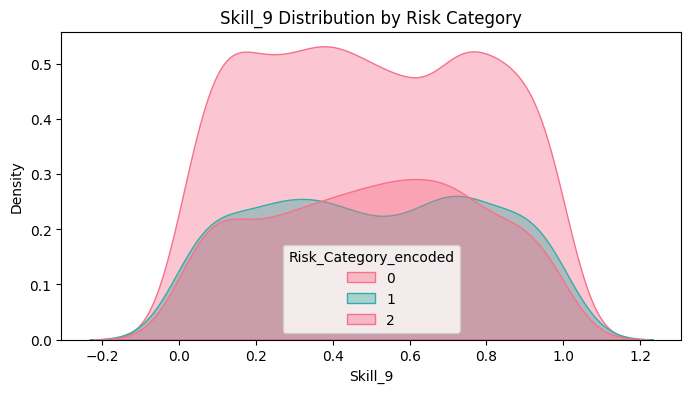

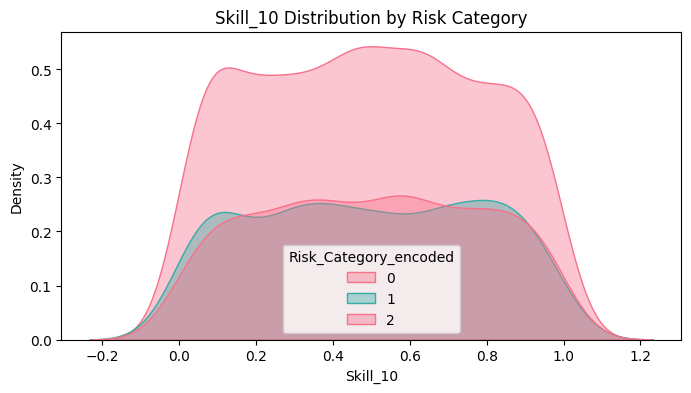

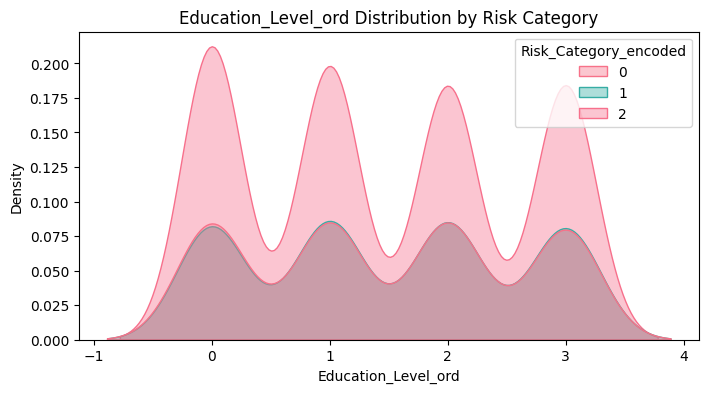

In [35]:
variables = ['Average_Salary', 'Years_Experience', 'AI_Exposure_Index',
             'Tech_Growth_Factor', 'Automation_Probability_2030',
             'Skill_1', 'Skill_2', 'Skill_3', 'Skill_4', 'Skill_5',
             'Skill_6', 'Skill_7', 'Skill_8', 'Skill_9', 'Skill_10',
             'Education_Level_ord']

# 1. Countplot — class distribution
plt.figure(figsize=(8,5))
sns.countplot(x='Risk_Category_encoded', data=df, hue='Risk_Category_encoded',palette='Set2',legend=False)
plt.title("Risk Category Distribution (0=High, 1=Low, 2=Medium)")
plt.xlabel("Risk Category Encoded")
plt.ylabel("Count")
plt.show()

# 2. Heatmap
plt.figure(figsize=(18, 14))
sns.heatmap(df.corr(numeric_only=True),
            annot=True, fmt=".2f", cmap='coolwarm',
            annot_kws={"size": 7},
            linewidths=0.5, linecolor='white')
plt.title("Correlation Heatmap — All Features vs Risk Category", fontsize=16)
plt.xticks(fontsize=8, rotation=45, ha='right')
plt.yticks(fontsize=8, rotation=0)
plt.tight_layout()
plt.show()

# 3. Boxplot
for var in variables:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x='Risk_Category_encoded', y=var,
                data=df)
    plt.title(f"Risk Category vs {var}")
    plt.xlabel("Risk Category (0=High, 1=Low, 2=Medium)")
    plt.ylabel(var)
    plt.show()

# 4. KDE Plot
for var in variables:
    plt.figure(figsize=(8, 4))
    sns.kdeplot(data=df, x=var,
                hue='Risk_Category_encoded',fill=True, palette='husl',alpha=0.4)
    plt.title(f"{var} Distribution by Risk Category")
    plt.show()

# Train Test Split and 3 models applied

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report,f1_score,recall_score,confusion_matrix,precision_score

X = df.select_dtypes(include='number').drop(
    columns=['Risk_Category_encoded', 
             'Automation_Probability_2030'])
y = df['Risk_Category_encoded']

print("\nFinal X shape:", X.shape)
print("Final y shape:", y.shape)
print("\nFeatures used:\n", X.columns.tolist())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("\nX_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

# 1. LOGISTIC REGRESSION
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("\n" + "=" * 50)
print("V3 — LOGISTIC REGRESSION")
print("=" * 50)
results_lr = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_lr})
print("Actual vs Predicted:\n", results_lr)
print(f'Accuracy  : {accuracy_score(y_test, y_pred_lr)*100:.2f}%')
print(f'Precision : {precision_score(y_test, y_pred_lr, average="weighted"):.4f}')
print(f'Recall    : {recall_score(y_test, y_pred_lr, average="weighted"):.4f}')
print(f'F1 Score  : {f1_score(y_test, y_pred_lr, average="weighted"):.4f}')
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))


# 2. KNN CLASSIFIER
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("\n" + "=" * 50)
print("V3 — KNN CLASSIFIER")
print("=" * 50)
results_knn = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_knn})
print("Actual vs Predicted:\n", results_knn)
print(f'Accuracy  : {accuracy_score(y_test, y_pred_knn)*100:.2f}%')
print(f'Precision : {precision_score(y_test, y_pred_knn, average="weighted"):.4f}')
print(f'Recall    : {recall_score(y_test, y_pred_knn, average="weighted"):.4f}')
print(f'F1 Score  : {f1_score(y_test, y_pred_knn, average="weighted"):.4f}')
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("Classification Report:\n", classification_report(y_test, y_pred_knn))

# 3. DECISION TREE CLASSIFIER
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("\n" + "=" * 50)
print("V3 — DECISION TREE CLASSIFIER")
print("=" * 50)
results_dt = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_dt})
print("Actual vs Predicted:\n", results_dt)
print(f'Accuracy  : {accuracy_score(y_test, y_pred_dt)*100:.2f}%')
print(f'Precision : {precision_score(y_test, y_pred_dt, average="weighted"):.4f}')
print(f'Recall    : {recall_score(y_test, y_pred_dt, average="weighted"):.4f}')
print(f'F1 Score  : {f1_score(y_test, y_pred_dt, average="weighted"):.4f}')
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))


Final X shape: (3000, 34)
Final y shape: (3000,)

Features used:
 ['Average_Salary', 'Years_Experience', 'AI_Exposure_Index', 'Tech_Growth_Factor', 'Skill_1', 'Skill_2', 'Skill_3', 'Skill_4', 'Skill_5', 'Skill_6', 'Skill_7', 'Skill_8', 'Skill_9', 'Skill_10', 'Education_Level_ord', 'Job_Title_Chef', 'Job_Title_Construction Worker', 'Job_Title_Customer Support', 'Job_Title_Data Scientist', 'Job_Title_Doctor', 'Job_Title_Financial Analyst', 'Job_Title_Graphic Designer', 'Job_Title_HR Specialist', 'Job_Title_Lawyer', 'Job_Title_Marketing Manager', 'Job_Title_Mechanic', 'Job_Title_Nurse', 'Job_Title_Research Scientist', 'Job_Title_Retail Worker', 'Job_Title_Security Guard', 'Job_Title_Software Engineer', 'Job_Title_Teacher', 'Job_Title_Truck Driver', 'Job_Title_UX Researcher']

X_train shape: (2400, 34)
X_test shape : (600, 34)

V3 — LOGISTIC REGRESSION
Actual vs Predicted:
       Actual  Predicted
1801       2          2
1190       0          0
1817       2          2
251        2        

In [ ]:
# V3 Classification Results:
# X = 34 features (Job_Title OHE + Education ordinal
#     + all numeric + skills)
# y = Risk_Category (0=High, 1=Low, 2=Medium)

# Logistic Regression: 99.17% — near perfect classification
# KNN: 99.17% — same as Logistic, all neighbors correctly classified
# Decision Tree: 97.67% — slightly lower, 14 misclassifications

# Key Finding: Job_Title encoding was the game changer
# Each job has a fixed Risk_Category in this dataset
# Security Guard/Truck Driver → High Risk
# Doctor/Teacher/Nurse → Low Risk

# V1 (47%) and V2 (47%) failed because Job_Title
# was not encoded — V3 with full encoding gave 99%+

# Job_Title → Risk_Category ka
# direct mapping hai dataset mein
# isliye 99% accuracy aana sahi hai

# Ensemble Learning Models

In [ ]:
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    BaggingClassifier
)

# X_train, X_test, y_train, y_test same V3 wale hain

# 1. RANDOM FOREST CLASSIFIER
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=" * 50)
print("ENSEMBLE — RANDOM FOREST CLASSIFIER")
print("=" * 50)
results_rf = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_rf})
print("Actual vs Predicted:\n", results_rf)
print(f'Accuracy  : {accuracy_score(y_test, y_pred_rf)*100:.2f}%')
print(f'Precision : {precision_score(y_test, y_pred_rf, average="weighted"):.4f}')
print(f'Recall    : {recall_score(y_test, y_pred_rf, average="weighted"):.4f}')
print(f'F1 Score  : {f1_score(y_test, y_pred_rf, average="weighted"):.4f}')
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

# 2. GRADIENT BOOSTING CLASSIFIER
gb = GradientBoostingClassifier(n_estimators=100,
                                 learning_rate=0.1,
                                 random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print("\n" + "=" * 50)
print("ENSEMBLE — GRADIENT BOOSTING CLASSIFIER")
print("=" * 50)
results_gb = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_gb})
print("Actual vs Predicted:\n", results_gb)
print(f'Accuracy  : {accuracy_score(y_test, y_pred_gb)*100:.2f}%')
print(f'Precision : {precision_score(y_test, y_pred_gb, average="weighted"):.4f}')
print(f'Recall    : {recall_score(y_test, y_pred_gb, average="weighted"):.4f}')
print(f'F1 Score  : {f1_score(y_test, y_pred_gb, average="weighted"):.4f}')
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))
print("Classification Report:\n", classification_report(y_test, y_pred_gb))


# 3. BAGGING CLASSIFIER

bag = BaggingClassifier(n_estimators=100, random_state=42)
bag.fit(X_train, y_train)
y_pred_bag = bag.predict(X_test)

print("\n" + "=" * 50)
print("ENSEMBLE — BAGGING CLASSIFIER")
print("=" * 50)
results_bag = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_bag})
print("Actual vs Predicted:\n", results_bag)
print(f'Accuracy  : {accuracy_score(y_test, y_pred_bag)*100:.2f}%')
print(f'Precision : {precision_score(y_test, y_pred_bag, average="weighted"):.4f}')
print(f'Recall    : {recall_score(y_test, y_pred_bag, average="weighted"):.4f}')
print(f'F1 Score  : {f1_score(y_test, y_pred_bag, average="weighted"):.4f}')
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_bag))
print("Classification Report:\n", classification_report(y_test, y_pred_bag))

ENSEMBLE — RANDOM FOREST CLASSIFIER
Actual vs Predicted:
       Actual  Predicted
1801       2          2
1190       0          0
1817       2          2
251        2          2
2505       2          2
...      ...        ...
104        2          2
2087       1          1
599        2          2
1756       2          2
1323       0          0

[600 rows x 2 columns]
Accuracy  : 96.83%
Precision : 0.9698
Recall    : 0.9683
F1 Score  : 0.9679
Confusion Matrix:
 [[167   0   0]
 [  0 132  17]
 [  2   0 282]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       167
           1       1.00      0.89      0.94       149
           2       0.94      0.99      0.97       284

    accuracy                           0.97       600
   macro avg       0.98      0.96      0.97       600
weighted avg       0.97      0.97      0.97       600


ENSEMBLE — GRADIENT BOOSTING CLASSIFIER
Actual vs Predicted:
       Actual  Predict

In [ ]:
# ENSEMBLE CLASSIFICATION — V3 Results
# X = 34 features (OHE + encoded + numeric)
# y = Risk_Category (0=High, 1=Low, 2=Medium)

# Gradient Boosting → Best (98.83%) — sequential
#                     learning corrected errors
# Bagging           → 98.50% — random subset training
# Random Forest     → 96.83% — class 1 weak (17 errors)

# Pure Classification models slightly outperformed
# Ensemble because Job_Title encoding creates very
# clear decision boundaries — simple models handle
# this well without needing complex ensembles

# In real-world noisy datasets, ensemble models
# would significantly outperform simple classifiers